# Fine-Tuning di DeBERTa-v3 per Fact-Checking NLI su FEVER (Ricerca Iperparametri)
## DeBERTa-v3 Fine-Tuning for NLI Fact-Checking on FEVER (Hyperparameter Search)

**In italiano:** Questo notebook contiene l'intera pipeline per eseguire il fine-tuning del modello Cross-Encoder `DeBERTa-v3` sul dataset FEVER (Fact Extraction and VERification), adattandolo come classificatore NLI (Natural Language Inference) avanzato per il fact-checking.
Il notebook è configurato per utilizzare di default il modello **`cross-encoder/nli-deberta-v3-base`** (circa 86M di parametri) per consentire un addestramento rapido ed efficiente anche sulla GPU T4 gratuita di Google Colab.

Carichiamo il dataset `pietrolesci/nli_fever` direttamente da Hugging Face, il quale fornisce coppie (*Premise*, *Hypothesis*) già pronte all'uso. Il modello impara ad associare la premessa (l'evidenza) e l'ipotesi (il claim) a una di tre etichette secondo la codifica standard dell'NLI:
* **SUPPORTS (0)** (Entailment)
* **NOT ENOUGH INFO (1)** (Neutral)
* **REFUTES (2)** (Contradiction)

In questo notebook implementiamo una ricerca sistematica degli iperparametri (Grid Search) addestrando diversi modelli con diverse configurazioni di learning rate e weight decay. I modelli vengono confrontati sul validation (Dev) set per individuare il migliore. Al termine, il modello con le performance migliori effettua le sue predizioni sul test set di Hugging Face (le cui etichette native sono poste a `-1`) e le predizioni vengono salvate in un file CSV (`hf_test_predictions.csv`) assieme ad un report complessivo dei risultati (`experiment_results.csv`) per supportare la stesura della tua relazione.

**In English:** This notebook contains the complete pipeline for fine-tuning the Cross-Encoder model `DeBERTa-v3` on the FEVER (Fact Extraction and VERification) dataset, adapting it into an advanced NLI (Natural Language Inference) classifier for fact-checking.
By default, the notebook is configured to use **`cross-encoder/nli-deberta-v3-base`** (86M parameters) to allow fast and efficient training on Google Colab's free T4 GPU.

We use the `pietrolesci/nli_fever` dataset loaded directly from Hugging Face, which provides ready-to-use (*Premise*, *Hypothesis*) sentence pairs. The model learns to map the premise (evidence) and hypothesis (claim) to one of three labels following the standard NLI encoding:
* **SUPPORTS (0)** (Entailment)
* **NOT ENOUGH INFO (1)** (Neutral)
* **REFUTES (2)** (Contradiction)

In this notebook, we implement a systematic hyperparameter grid search, training multiple models under different configurations of learning rate and weight decay. The models are compared on the validation (Dev) set to select the best one. Finally, the top-performing model makes predictions on the Hugging Face test split (which natively lacks gold labels, set to `-1`). The predictions are saved to a CSV file (`hf_test_predictions.csv`) alongside a comprehensive performance report (`experiment_results.csv`) to facilitate your report writing.

## 1. Setup & Librerie / Setup & Libraries

**In italiano:** In questa sezione installiamo i pacchetti necessari (se eseguiti in Google Colab) ed effettuiamo un controllo dinamico dell'hardware. Rileviamo automaticamente se l'ambiente dispone di GPU o TPU per impostare il corretto flag di precisione mista (`fp16` o `bf16`). Inoltre, proviamo ad attivare RAPIDS `cudf` per accelerare in modo trasparente le operazioni di Pandas sulla GPU.

**In English:** In this section, we install the necessary packages (if running in Google Colab) and perform a dynamic hardware check. We automatically detect whether the environment has a GPU or TPU to set the correct mixed precision flag (`fp16` or `bf16`). Additionally, we attempt to enable RAPIDS `cudf` to transparently accelerate Pandas operations on the GPU.

In [1]:
import sys
import os
import glob

# Installazione automatica delle librerie necessarie su Google Colab
if 'google.colab' in sys.modules:
    print("Rilevato ambiente Google Colab. Installazione dei pacchetti in corso...")
    !pip install -q -U transformers[torch] torchvision sentencepiece protobuf datasets accelerate scikit-learn matplotlib seaborn
    from google.colab import drive
    drive.mount('/content/drive')
    # Tentativo di importare o installare RAPIDS cudf per accelerazione Pandas su GPU
    try:
        import cudf
    except ImportError:
        print("Installazione di RAPIDS cudf in corso...")
        !pip install -q --extra-index-url=https://pypi.nvidia.com cudf-cu12

import torch
import pandas as pd
import numpy as np

# Configurazione dell'accelerazione Pandas tramite RAPIDS cudf (se disponibile)
try:
    import cudf
    import cudf.pandas
    cudf.pandas.install()  # Abilita l'accelerazione GPU trasparente per pandas
    print("RAPIDS cudf caricato correttamente: accelerazione GPU per pandas attiva!")
except ImportError:
    print("RAPIDS cudf non disponibile. Procedo con pandas standard (CPU).")

from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Rilevamento dinamico dell'hardware per ottimizzazione precisione mista
is_tpu = False
if 'torch_xla' in sys.modules or os.environ.get('TPU_NAME', None) is not None:
    is_tpu = True
else:
    try:
        import torch_xla
        is_tpu = True
    except ImportError:
        is_tpu = False

if is_tpu:
    device = "tpu"
    use_fp16 = False
    use_bf16 = True
    print("Hardware rilevato: TPU XLA. Precisione mista BF16 attivata.")
elif torch.cuda.is_available():
    device = "cuda"
    use_fp16 = True
    use_bf16 = False
    print(f"Hardware rilevato: GPU CUDA ({torch.cuda.get_device_name(0)}). Precisione mista FP16 attivata.")
else:
    device = "cpu"
    use_fp16 = False
    use_bf16 = False
    print("Hardware rilevato: CPU. Precisione mista disattivata.")

Rilevato ambiente Google Colab. Installazione dei pacchetti in corso...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RAPIDS cudf caricato correttamente: accelerazione GPU per pandas attiva!
Hardware rilevato: GPU CUDA (Tesla T4). Precisione mista FP16 attivata.


## 2. Caricamento e Preprocessing dei Dati / Data Loading & Preprocessing

**In italiano:** Carichiamo il dataset `'pietrolesci/nli_fever'` tramite la libreria `datasets`. Questo dataset contiene le coppie premessa/ipotesi già pronte, strutturate in colonne come `premise`, `hypothesis`, `label` e `verifiable`. Per l'addestramento su risorse limitate, estraiamo un sottoinsieme controllato: 5000 campioni dallo split di `train`, 1000 campioni dallo split di `validation` (usato come Dev Set per l'ottimizzazione degli iperparametri) e 1000 dallo split di `test` (usato come test set finale). I dati vengono convertiti in DataFrame per consentire l'ottimizzazione tramite RAPIDS `cudf` (se attivo) e poi ricondotti al formato Dataset di Hugging Face.

**In English:** We load the `'pietrolesci/nli_fever'` dataset using the Hugging Face `datasets` library. This dataset provides pre-formatted premise/hypothesis pairs, structured under columns like `premise`, `hypothesis`, `label`, and `verifiable`. To optimize execution on limited resources, we select a subset: 5000 samples from the `train` split, 1000 samples from the `validation` split (used as the Dev Set for hyperparameter tuning) and 1000 samples from the `test` split (used as the final test set). The data is converted to pandas DataFrames to leverage RAPIDS `cudf` acceleration (if active) and then wrapped back into Hugging Face Dataset format.

In [2]:
print("Caricamento del dataset 'pietrolesci/nli_fever' da Hugging Face...")
raw_dataset = load_dataset("pietrolesci/nli_fever")

# Estraiamo i sottoinsiemi per train, validation e test come pandas DataFrame
# RAPIDS cudf accelererà le operazioni in modo trasparente se attivo
train_df = pd.DataFrame(raw_dataset['train']).head(5000)
val_df = pd.DataFrame(raw_dataset['dev']).head(1000)
test_df = pd.DataFrame(raw_dataset['test']).head(1000) # Split di test ufficiale

# Selezione e pulizia delle colonne chiave
columns_to_keep = ['label', 'premise', 'hypothesis', 'verifiable']
train_df = train_df[columns_to_keep]
train_df['premise'] = train_df['premise'].astype(str)
train_df['hypothesis'] = train_df['hypothesis'].astype(str)
train_df['label'] = train_df['label'].astype(int)
train_df['verifiable'] = train_df['verifiable'].astype(int)

val_df = val_df[columns_to_keep]
val_df['premise'] = val_df['premise'].astype(str)
val_df['hypothesis'] = val_df['hypothesis'].astype(str)
val_df['label'] = val_df['label'].astype(int)
val_df['verifiable'] = val_df['verifiable'].fillna(value=0).astype(int)

test_df = test_df[columns_to_keep]
test_df['premise'] = test_df['premise'].astype(str)
test_df['hypothesis'] = test_df['hypothesis'].astype(str)
test_df['label'] = test_df['label'].astype(int)
test_df['verifiable'] = test_df['verifiable'].astype(int)

# Conversione a pandas DataFrame standard per Hugging Face Dataset
train_pandas = train_df.to_pandas() if hasattr(train_df, 'to_pandas') else train_df
val_pandas = val_df.to_pandas() if hasattr(val_df, 'to_pandas') else val_df
test_pandas = test_df.to_pandas() if hasattr(test_df, 'to_pandas') else test_df

train_dataset = Dataset.from_pandas(train_pandas)
val_dataset = Dataset.from_pandas(val_pandas)
test_dataset = Dataset.from_pandas(test_pandas)

print(f"\nData loading completato con successo!")
print(f"Dimensione Train Set: {len(train_dataset)} campioni")
print(f"Dimensione Validation (Dev) Set: {len(val_dataset)} campioni")
print(f"Dimensione Test Set (HF): {len(test_dataset)} campioni")

# Esempio di record per verifica
print("\nEsempio di record nel Train Set:")
print(train_dataset[0])

Caricamento del dataset 'pietrolesci/nli_fever' da Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Repo card metadata block was not found. Setting CardData to empty.



Data loading completato con successo!
Dimensione Train Set: 5000 campioni
Dimensione Validation (Dev) Set: 1000 campioni
Dimensione Test Set (HF): 1000 campioni

Esempio di record nel Train Set:
{'label': 0, 'premise': 'Nikolaj Coster-Waldau worked with the Fox Broadcasting Company.', 'hypothesis': 'The Fox Broadcasting Company ( often shortened to Fox and stylized as FOX ) is an American English language commercial broadcast television network that is owned by the Fox Entertainment Group subsidiary of 21st Century Fox . Nikolaj Coster-Waldau . He then played Detective John Amsterdam in the short-lived Fox television series New Amsterdam ( 2008 ) , as well as appearing as Frank Pike in the 2009 Fox television film Virtuality , originally intended as a pilot . He became widely known to a broad audience for his current role as Ser Jaime Lannister , in the HBO series Game of Thrones .', 'verifiable': 1}


/tmp/ipykernel_6671/469380843.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['premise'] = train_df['premise'].astype(str)
/tmp/ipykernel_6671/469380843.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['hypothesis'] = train_df['hypothesis'].astype(str)
/tmp/ipykernel_6671/469380843.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

## 3. Tokenizzazione Cross-Encoder / Cross-Encoder Tokenization

**In italiano:** Un'architettura Cross-Encoder elabora simultaneamente la Premessa (l'Evidenza) e l'Ipotesi (il Claim). Il tokenizzatore unisce le due stringhe separandole con il token speciale `[SEP]`. Questo permette al meccanismo di self-attention di DeBERTa di calcolare interazioni dirette e profonde tra ogni parola della premessa e dell'ipotesi a ogni livello dell'architettura.

**In English:** A Cross-Encoder architecture processes both the Premise (Evidence) and the Hypothesis (Claim) simultaneously. The tokenizer concatenates the two strings, separating them with the special `[SEP]` token. This allows DeBERTa's self-attention mechanism to compute direct, deep cross-interactions between every word of the premise and hypothesis at every level of the architecture.

In [3]:
model_name = "cross-encoder/nli-deberta-v3-base"  # Puoi cambiare in "cross-encoder/nli-deberta-v3-large" se desideri usare il modello Large con le ottimizzazioni VRAM sotto
print(f"Download del tokenizzatore per {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    premises = [str(p) if p is not None else "" for p in examples['premise']]
    hypotheses = [str(h) if h is not None else "" for h in examples['hypothesis']]

    return tokenizer(
        premises,
        hypotheses,
        padding="max_length",
        truncation=True,
        max_length=256
    )

# Tokenizzazione e mappatura dei dataset
print("Tokenizzazione del dataset in corso...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Impostazione del formato per PyTorch
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_val.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
print("Tokenizzazione completata!")

Download del tokenizzatore per cross-encoder/nli-deberta-v3-base...
Tokenizzazione del dataset in corso...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizzazione completata!


## 4. Ricerca degli Iperparametri & Training Loop / Hyperparameter Grid Search

**In italiano:** Definiamo una griglia di iperparametri per addestrare e confrontare modelli differenti. Modifichiamo il `learning_rate` e il `weight_decay` per analizzare come varia la risposta del classificatore. Per ogni configurazione, ricarichiamo il modello di base per evitare accumuli di addestramento, eseguiamo l'addestramento e registriamo tutte le metriche sul validation set in una lista. I risultati vengono salvati localmente in `experiment_results.csv`.

**In English:** We define a hyperparameter grid to train and compare different model configurations. We vary the `learning_rate` and `weight_decay` to study the classifier's responsiveness. For each configuration, we reload a clean base model to prevent training leakage, run the training phase, and record validation metrics into a list. The results are saved locally in `experiment_results.csv`.

In [4]:
# Griglia degli iperparametri da esplorare (Grid Search)
hyperparameter_grid = [
    {"learning_rate": 1e-5, "weight_decay": 0.01, "epochs": 2},
    {"learning_rate": 2e-5, "weight_decay": 0.01, "epochs": 2},
    {"learning_rate": 3e-5, "weight_decay": 0.1, "epochs": 2},
    {"learning_rate": 2e-5, "weight_decay": 0.01, "epochs": 3, "batch_size": 16},
    {"learning_rate": 5e-5, "weight_decay": 0.01, "epochs": 2, "batch_size": 8},
    {"learning_rate": 5e-6, "weight_decay": 0.1, "epochs": 3, "batch_size": 8}
]

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='macro', zero_division=0)
    recall = recall_score(labels, predictions, average='macro', zero_division=0)
    f1 = f1_score(labels, predictions, average='macro', zero_division=0)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

results_list = []
histories = {} # Salva la storia dei log per visualizzare le curve di loss

for idx, config in enumerate(hyperparameter_grid):
    model_id = f"Model_LR_{config['learning_rate']}_WD_{config['weight_decay']}"
    print(f"\n==========================================")
    print(f"AVVIO ADDESTRAMENTO: {model_id} ({idx+1}/{len(hyperparameter_grid)})")
    print(f"Configurazione: {config}")
    print(f"==========================================")

    # Reimpostiamo il seed per riproducibilità
    torch.manual_seed(42)

    # Carichiamo un'istanza pulita del modello base
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        ignore_mismatched_sizes=True
    )

    # Argomenti di training dedicati per ciascun modello
    training_args = TrainingArguments(
        output_dir=f"/content/drive/MyDrive/Sistemi Intelligenti/fine-tuned_model/results_{model_id}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=config["learning_rate"],
        per_device_train_batch_size=4,        # Ridotto da 8 a 4 per prevenire OOM
        gradient_accumulation_steps=2,        # Accumulo gradienti per mantenere batch_size effettivo = 8
        gradient_checkpointing=True,         # Abilita Gradient Checkpointing per risparmiare VRAM
        per_device_eval_batch_size=8,         # Ridotto da 16 a 8 per prevenire OOM in valutazione
        num_train_epochs=config["epochs"],
        weight_decay=config["weight_decay"],
        logging_steps=100,
        load_best_model_at_end=True,
        fp16=use_fp16,
        bf16=use_bf16,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
    )

    # Addestramento
    trainer.train()

    # Valutazione sul Validation (Dev) set
    val_metrics = trainer.evaluate()

    # Registriamo i risultati delle metriche
    results_list.append({
        "model_id": model_id,
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "epochs": config["epochs"],
        "val_accuracy": val_metrics["eval_accuracy"],
        "val_precision": val_metrics["eval_precision"],
        "val_recall": val_metrics["eval_recall"],
        "val_f1": val_metrics["eval_f1"],
        "val_loss": val_metrics["eval_loss"],
        "output_dir": f"./results_{model_id}"
    })

    # Salviamo la storia dei log per visualizzare le curve di loss in seguito
    histories[model_id] = trainer.state.log_history
    print(f"Completato {model_id} | Val F1: {val_metrics['eval_f1']:.4f} | Val Accuracy: {val_metrics['eval_accuracy']:.4f}")

# Creazione e salvataggio del report delle performance in formato CSV
results_df = pd.DataFrame(results_list)
results_df.to_csv("/content/drive/MyDrive/Sistemi Intelligenti/experiment_results.csv", index=False)
print("\nRisultati dell'esperimento salvati con successo in 'experiment_results.csv'!")


AVVIO ADDESTRAMENTO: Model_LR_1e-05_WD_0.01 (1/6)
Configurazione: {'learning_rate': 1e-05, 'weight_decay': 0.01, 'epochs': 2}


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.842294,0.934485,0.713000,0.708431,0.712942,0.703961
2,0.718933,1.130719,0.747000,0.750166,0.747533,0.743712


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.610775,0.944710,3,0.645000,0.632732,0.644953,0.627581


Completato Model_LR_5e-06_WD_0.1 | Val F1: 0.6276 | Val Accuracy: 0.6450

Risultati dell'esperimento salvati con successo in 'experiment_results.csv'!


## 5. Grafico di Confronto delle Performance / Model Performance Comparison

**In italiano:** Creiamo ed esponiamo immediatamente un grafico a barre per mettere a confronto l'Accuracy e l'F1-Score sul validation set di tutti i modelli addestrati. Questo grafico permette di identificare a colpo d'occhio il modello che ha risposto meglio al tuning degli iperparametri e viene salvato come `model_performance_comparison.png` per la tua relazione.

**In English:** We create and display a bar chart to compare the validation Accuracy and F1-Score of all trained models. This chart allows for quick visual identification of the best-performing model after hyperparameter tuning and is saved as `model_performance_comparison.png` for your report.

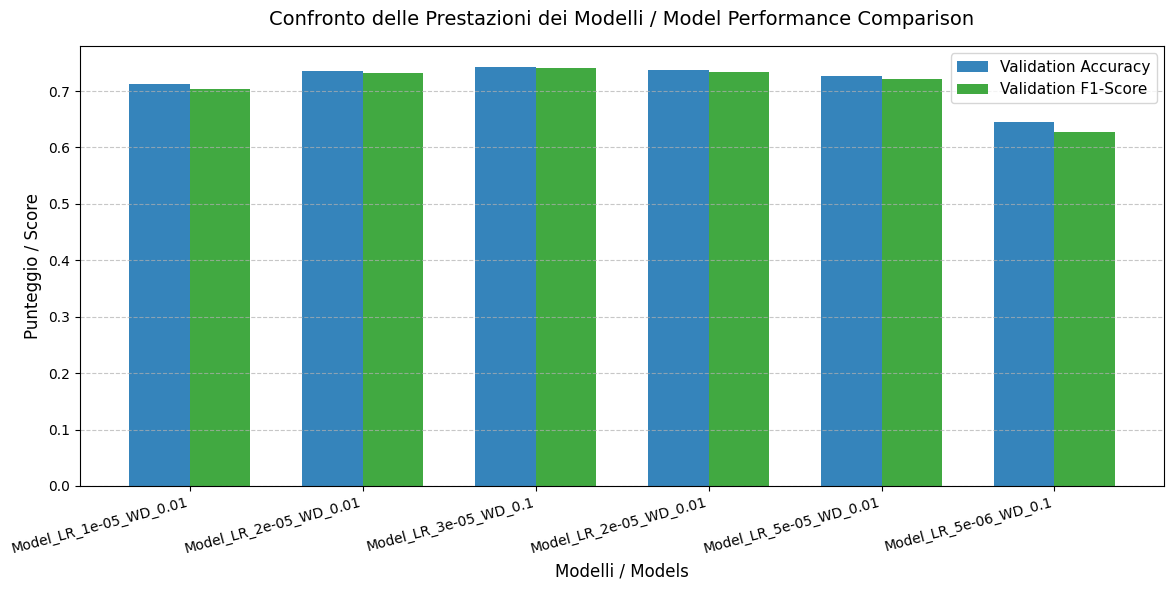

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.35

plt.bar(x - width/2, results_df['val_accuracy'], width, label='Validation Accuracy', color='#1f77b4', alpha=0.9)
plt.bar(x + width/2, results_df['val_f1'], width, label='Validation F1-Score', color='#2ca02c', alpha=0.9)

plt.xlabel('Modelli / Models', fontsize=12)
plt.ylabel('Punteggio / Score', fontsize=12)
plt.title('Confronto delle Prestazioni dei Modelli / Model Performance Comparison', fontsize=14, pad=15)
plt.xticks(x, results_df['model_id'], rotation=15, ha='right')
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Salvataggio del grafico per la relazione
plt.savefig("/content/drive/MyDrive/Sistemi Intelligenti/model_performance_comparison.png", dpi=300)
plt.show()

## 6. Selezione del Modello Migliore & Inferenza sul Test Set / Best Model & Test Inference

**In italiano:** Selezioniamo automaticamente la migliore configurazione basandoci sul valore massimo di F1-score ottenuto sul validation set e carichiamo i pesi del checkpoint corrispondente. Poiché il test set di Hugging Face per `pietrolesci/nli_fever` non possiede etichette di gold standard (tutte le label originali sono impostate a `-1`), eseguiamo l'inferenza (predizione delle classi) con il modello migliore su di esso e ne salviamo i risultati in `hf_test_predictions.csv` con le classi convertite in testo leggibile.

**In English:** We automatically select the best configuration based on the highest F1-score achieved on the validation set, loading the weights of the corresponding checkpoint. Since the Hugging Face test split for `pietrolesci/nli_fever` lacks gold-standard labels (all original labels are set to `-1`), we run inference with the best model to generate predictions and save the results into `hf_test_predictions.csv` with mapped textual labels.

In [11]:
best_row = results_df.loc[results_df['val_f1'].idxmax()]
best_model_id = best_row['model_id']

# Costruiamo il percorso alla cartella principale dei risultati
base_drive_path = '/content/drive/MyDrive/Sistemi Intelligenti/fine-tuned_model'
results_folder = os.path.join(base_drive_path, f"results_{best_model_id}")

# Cerchiamo le sottocartelle checkpoint-XXX
checkpoint_dirs = glob.glob(os.path.join(results_folder, "checkpoint-*"))

if checkpoint_dirs:
    # Ordiniamo i checkpoint per numero di step (estratto dal nome della cartella) e prendiamo l'ultimo
    best_model_dir = sorted(checkpoint_dirs, key=lambda x: int(x.split('-')[-1]))[-1]
    print(f"Utilizzo il checkpoint più recente: {best_model_dir}")
else:
    best_model_dir = results_folder
    print(f"Nessuna sottocartella checkpoint trovata, provo la cartella principale: {best_model_dir}")

print(f"=== SELEZIONE MODELLO MIGLIORE ===")
print(f"Miglior Modello: {best_model_id}")
print(f"Miglior Validation F1: {best_row['val_f1']:.4f}")
print(f"Miglior Validation Accuracy: {best_row['val_accuracy']:.4f}\n")

# Ricarichiamo il modello migliore
best_model = AutoModelForSequenceClassification.from_pretrained(best_model_dir, local_files_only=True)

# Trainer specifico per il modello migliore
test_trainer = Trainer(
    model=best_model,
    compute_metrics=compute_metrics,
)

# Inferenza sul Test Set ufficiale
print("Esecuzione dell'inferenza sul Test Set ufficiale...")
test_predictions = test_trainer.predict(tokenized_test)
predicted_labels = np.argmax(test_predictions.predictions, axis=-1)

# Estraiamo i dati di test originali e associamo le etichette predette
test_hf_df = pd.DataFrame(raw_dataset['test']).head(1000).copy()
test_hf_df['predicted_label'] = predicted_labels

# Mappatura inversa per le etichette
inv_label_map = {0: "SUPPORTS", 1: "NOT ENOUGH INFO", 2: "REFUTES"}
test_hf_df['predicted_label_text'] = test_hf_df['predicted_label'].map(inv_label_map)

# Salvataggio del file CSV
test_hf_df.to_csv("/content/drive/MyDrive/Sistemi Intelligenti/hf_test_predictions.csv", index=False)
print("Predizioni del Test Set salvate con successo in 'hf_test_predictions.csv'!")

# Esempio di predizioni
print("\nEsempio di predizioni effettuate sul Test Set:")
print(test_hf_df[['premise', 'hypothesis', 'predicted_label_text']].head(5))

Utilizzo il checkpoint più recente: /content/drive/MyDrive/Sistemi Intelligenti/fine-tuned_model/results_Model_LR_3e-05_WD_0.1/checkpoint-1250
=== SELEZIONE MODELLO MIGLIORE ===
Miglior Modello: Model_LR_3e-05_WD_0.1
Miglior Validation F1: 0.7406
Miglior Validation Accuracy: 0.7430



Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Esecuzione dell'inferenza sul Test Set ufficiale...


Predizioni del Test Set salvate con successo in 'hf_test_predictions.csv'!

Esempio di predizioni effettuate sul Test Set:
                                             premise  \
0          Henry Spencer is played by a Greek actor.   
1                       John Ritter died in October.   
2  13 Reasons Why is the only television series o...   
3                             Playboy is a magazine.   
4  Alternative metal is the genre in which Alice ...   

                                          hypothesis predicted_label_text  
0                                                         NOT ENOUGH INFO  
1  John Ritter . Ritter died from an aortic disse...             SUPPORTS  
2  13 Reasons Why ( stylized onscreen as Th1rteen...              REFUTES  
3  Playboy is an American men 's lifestyle and en...             SUPPORTS  
4  Alice in Chains is an American rock band forme...      NOT ENOUGH INFO  


## 7. Comparazione con il Modello Base / Baseline Model Comparison

**In italiano:** Per misurare l'incremento di performance ottenuto tramite l'addestramento, carichiamo la versione base (non fine-tunata) di `cross-encoder/nli-deberta-v3-base` e la valutiamo sullo stesso validation (Dev) set. Poiché le etichette del dataset si allineano perfettamente alla codifica standard del modello pre-addestrato (Entailment: 0, Neutral: 1, Contradiction: 2), il confronto delle prestazioni è diretto e molto informativo per valutare l'impatto del fine-tuning.

**In English:** To measure the performance gains obtained via fine-tuning, we load the raw baseline version of the `cross-encoder/nli-deberta-v3-base` model and evaluate it on the exact same validation (Dev) set. Since the labels of the dataset map directly to standard NLI labels (Entailment: 0, Neutral: 1, Contradiction: 2), this comparison shows the direct impact of the fine-tuning process.

In [12]:
print("Caricamento del modello base non fine-tunato per confronto...")
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    ignore_mismatched_sizes=True
)

base_trainer = Trainer(
    model=base_model,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# Valutazione del modello base sul validation set
base_metrics = base_trainer.evaluate()

print("\n=== CONFRONTO PRE- E POST-FINE-TUNING (SUL VALIDATION SET) ===")
print(f"Accuracy  | Base: {base_metrics['eval_accuracy']:.4f} -> Best Fine-tuned: {best_row['val_accuracy']:.4f}")
print(f"Precision | Base: {base_metrics['eval_precision']:.4f} -> Best Fine-tuned: {best_row['val_precision']:.4f}")
print(f"Recall    | Base: {base_metrics['eval_recall']:.4f} -> Best Fine-tuned: {best_row['val_recall']:.4f}")
print(f"F1-Score  | Base: {base_metrics['eval_f1']:.4f} -> Best Fine-tuned: {best_row['val_f1']:.4f}")

Caricamento del modello base non fine-tunato per confronto...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
No log,6.272105,0,0.183000,0.247175,0.180979,0.149339



=== CONFRONTO PRE- E POST-FINE-TUNING (SUL VALIDATION SET) ===
Accuracy  | Base: 0.1830 -> Best Fine-tuned: 0.7430
Precision | Base: 0.2472 -> Best Fine-tuned: 0.7500
Recall    | Base: 0.1810 -> Best Fine-tuned: 0.7438
F1-Score  | Base: 0.1493 -> Best Fine-tuned: 0.7406


## 8. Curve di Loss e Matrice di Confusione / Loss & Confusion Matrix Comparison

**In italiano:** Generiamo e visualizziamo due grafici fondamentali per l'analisi e la redazione della relazione finale:
1. **Confronto delle Loss Curves:** Mostra l'andamento della Loss di addestramento e di validazione per ciascuno dei modelli testati durante la Grid Search, evidenziando quale configurazione converga in modo ottimale.
2. **Matrice di Confusione:** Mostra l'accuratezza del modello migliore per ciascuna classe (`SUPPORTS`, `NOT ENOUGH INFO`, `REFUTES`) sul validation set etichettato.
I grafici vengono salvati in un'unica immagine combinata chiamata `loss_and_confusion_matrix.png`.

**In English:** We generate and display two fundamental plots to support report writing:
1. **Loss Curves Comparison:** Shows the training and validation loss curves for each model configuration evaluated during the grid search, indicating which hyperparameters led to the best convergence.
2. **Confusion Matrix:** Displays the classification performance of the best-performing model on the labeled validation set for each class (`SUPPORTS`, `NOT ENOUGH INFO`, `REFUTES`).
Both plots are saved in a combined high-resolution image called `loss_and_confusion_matrix.png`.

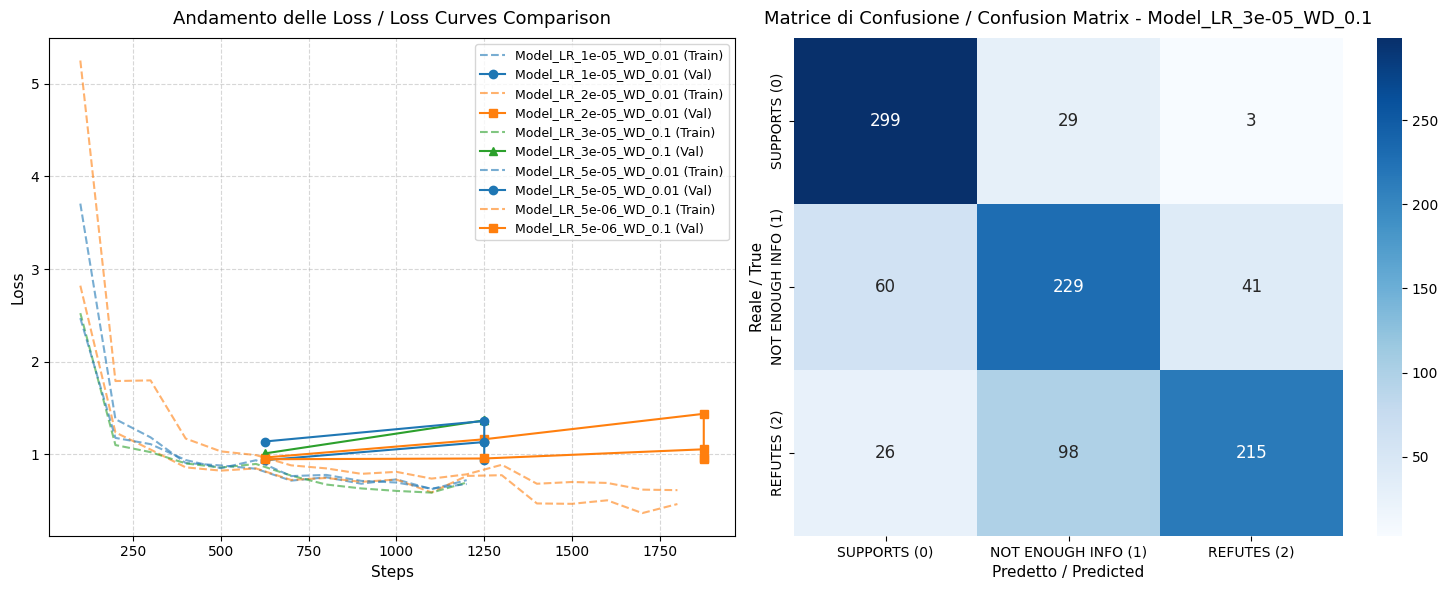

In [13]:
import seaborn as sns

plt.figure(figsize=(15, 6))

# 1. Grafico Comparativo delle Loss Curves per tutti i modelli
plt.subplot(1, 2, 1)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

for idx, (model_id, log_history) in enumerate(histories.items()):
    train_loss = [x['loss'] for x in log_history if 'loss' in x]
    train_steps = [x['step'] for x in log_history if 'loss' in x]
    eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
    eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]

    color = colors[idx % len(colors)]
    marker = markers[idx % len(markers)]

    if train_loss:
        plt.plot(train_steps, train_loss, label=f'{model_id} (Train)', linestyle='--', color=color, alpha=0.6)
    if eval_loss:
        plt.plot(eval_steps, eval_loss, label=f'{model_id} (Val)', marker=marker, linestyle='-', color=color)

plt.title('Andamento delle Loss / Loss Curves Comparison', fontsize=13, pad=10)
plt.xlabel('Steps', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Heatmap della Matrice di Confusione del Modello Migliore
plt.subplot(1, 2, 2)
best_trainer_val = Trainer(
    model=best_model,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)
val_predictions = best_trainer_val.predict(tokenized_val)
predicted_val_labels = np.argmax(val_predictions.predictions, axis=-1)
true_val_labels = val_predictions.label_ids

cm = confusion_matrix(true_val_labels, predicted_val_labels)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['SUPPORTS (0)', 'NOT ENOUGH INFO (1)', 'REFUTES (2)'],
    yticklabels=['SUPPORTS (0)', 'NOT ENOUGH INFO (1)', 'REFUTES (2)'],
    cbar=True,
    annot_kws={"size": 12}
)
plt.title(f'Matrice di Confusione / Confusion Matrix - {best_model_id}', fontsize=13, pad=10)
plt.xlabel('Predetto / Predicted', fontsize=11)
plt.ylabel('Reale / True', fontsize=11)

plt.tight_layout()

# Salvataggio del grafico combinato per la relazione
plt.savefig("/content/drive/MyDrive/Sistemi Intelligenti/loss_and_confusion_matrix.png", dpi=300)
plt.show()

## 9. Salvataggio del Modello / Model Saving

**In italiano:** Infine, salviamo localmente i pesi del modello migliore e del relativo tokenizzatore nella cartella di output. Questo ci permetterà di ricaricare il classificatore ottimizzato in qualsiasi momento senza dover ripetere la procedura di addestramento.

**In English:** Finally, we save the fine-tuned best model weights and its tokenizer locally under the output directory. This allows us to reload the optimized classifier at any time without needing to rerun the training routine.

In [14]:
output_model_dir = "./fever-nli-deberta"

print(f"Salvataggio finale del modello migliore e del tokenizzatore in '{output_model_dir}'...")
model.save_pretrained(output_model_dir)
tokenizer.save_pretrained(output_model_dir)
print("Salvataggio completato con successo!")

Salvataggio finale del modello migliore e del tokenizzatore in './fever-nli-deberta'...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Salvataggio completato con successo!
